# EEG Seizure Detection: Advanced Models (Task 2)
This notebook focuses on **Task 2: Forecasting**. The objective is to develop a predictive system capable of identifying the **pre-ictal** state, defined as the window of up to 10 minutes prior to seizure onset. Unlike detection, forecasting aims to provide an _early warning signal_ while the patient is still in an **inter-ictal or pre-ictal** phase. We evaluate a comprehensive suite of classical and deep learning algorithms to establish a robust predictive benchmark.

**Notebook Workflow**

1. [**Data Loading & Preparation**](#2-data): we import pre-processed features and labels for a specific subject (e.g., `chb12`). Data is loaded from chronological splits to ensure the model is tested on "future" data and then exploded by channel.
2. [**Baseline Training**](#4-train-baselines): we evaluate 10 different classical models:
    * Linear Models: Logistic Regression, SVM.
    * Probabilistic: Naive Bayes.
    * Distance/Neighbor-based: KNN.
    * Ensemble/Tree-based: Random Forest, XGBoost, LightGBM.
    * Statistical based: Hidden Markov Chain.
    * Deep Learning: 1d Convolutional Neural Network, Recurrent Neural Network.
3. [**Handling Imbalance**](#3-helpers): we apply specific class weights and `scale_pos_weight` to address the rarity of seizure events compared to normal activity.
4. [**Hyperparameter Tuning**](#5-hypertune-top-3): we identify the top 3 performing models based on the Validation F1-score and perform an automated search (Randomized/Grid Search) to optimize their settings.
5. [**Performance Evaluation**](#6-results): Models are compared using metrics crucial for medical safety, specifically **F1-score** and **Recall (Sensitivity)**, to ensure we minimize missed seizures.
6. **Pretrained Model exportation**: we exported the best model hypertuned and pretrained on the subject chosed in order to use for further analysis.

## 1. Setup

In [15]:
import os
import sys
from pathlib import Path
import warnings

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

warnings.filterwarnings("ignore")

cur_dir = Path(os.getcwd()).resolve()
proj_dir = next(parent for parent in [cur_dir, *cur_dir.parents] if (parent / "utils").exists() and (parent / "data").exists())

from utils.models.hmm import HiddenMarkovModel

from utils.models.deep_learning import ConvNetModel, RecurrentNetModel
from utils.model_io import save_model

print("Imports successful")

RANDOM_STATE = 42
N_JOBS = -1

SAVE = True
SAVE_PLOT_PATH = proj_dir / "doc" / "src" / "models"


Imports successful


## 2. Data

Subject `chb12` was selected as the primary test case due to the _high frequency of seizure events recorded_ for this patient. This provides a statistically significant number of pre-ictal transitions, which is essential for training complex models and ensuring the generalizability of the forecasting results.

To further augment the training set, we implemented a channel-agnostic approach by **pooling data from all available channels**. Instead of focusing on a single lead, this 'explosion' of samples allows the models to learn more diverse spatial representations of the pre-ictal state, significantly increasing the volume of data available for the deep learning architectures.

In [16]:
SELECTED_SUBJ = "chb12"
SPLIT_PATH = proj_dir / "data" / "split" / "task_2" / SELECTED_SUBJ
SELECTED_FILES = sorted([f.stem for f in SPLIT_PATH.glob("*.npz")])
BALANCE_TRAIN = False

def class_counts(y):
    return np.bincount(np.asarray(y).astype(int), minlength=2)

def load_file_pooled(file_name):
    """
    Loads a file and pools all channels together as separate samples.
    Strips channel names from features to ensure column alignment.
    """
    file_path = SPLIT_PATH / f"{file_name}.npz"
    data = np.load(file_path, allow_pickle=True)
    
    orig_train_size = len(data["X_train"])
    channels = data["channels"]
    feature_names = data["feature_names"]
    
    # Pre-identify the base feature names (removing the "Channel_" prefix)
    # first channel's features as a template to select the others
    first_ch = str(channels[0])
    base_names = [name.replace(f"{first_ch}_", "") for name in feature_names if name.startswith(f"{first_ch}_")]
    
    combined_frames = {"train": [], "val": [], "test": []}
    
    for ch_name in channels:
        ch_name = str(ch_name)
        # find indices for this specific channel
        idx = [i for i, name in enumerate(feature_names) if name.startswith(f"{ch_name}_")]
        
        if len(idx) == 0: continue
            
        for split in ["train", "val", "test"]:
            X_split = data[f"X_{split}"][:, idx]
            y_split = data[f"y_{split}"]
            
            # Create frame with generic names (e.g., 'delta_pwr' instead of 'FP1-F7_delta_pwr')
            df = pd.DataFrame(X_split, columns=base_names)
            df["is_seizure"] = np.asarray(y_split).astype(int)
            # keep track of which channel the sample came from
            df["original_channel"] = ch_name 
            
            combined_frames[split].append(df)
            
    # stack all channels for each split
    final_splits = {
        split: pd.concat(combined_frames[split], ignore_index=True) 
        for split in ["train", "val", "test"]
    }
    
    print(f"Loaded {file_name} (original size = {orig_train_size})| Pooled {len(channels)} channels | New Train Size: {len(final_splits['train'])}")
    return final_splits

# 1. Load and Pool
loaded = [load_file_pooled(f_name) for f_name in SELECTED_FILES]
# 2. Global Concatenation
split_frames = {
    split: pd.concat([f[split] for f in loaded], ignore_index=True)
    for split in ["train", "val", "test"]
}
# 3. Balancing (if required)
if BALANCE_TRAIN:
    pos = split_frames["train"][split_frames["train"]["is_seizure"] == 1]
    neg = split_frames["train"][split_frames["train"]["is_seizure"] == 0].sample(len(pos), random_state=RANDOM_STATE)
    split_frames["train"] = pd.concat([pos, neg], ignore_index=True).sample(frac=1, random_state=RANDOM_STATE)
# 4. Final Audit
for split, df in split_frames.items():
    counts = class_counts(df["is_seizure"])
    print(f"{split:5s}: {df.shape} | Class distribution: {counts}")

Loaded chb12_06 (original size = 1526)| Pooled 26 channels | New Train Size: 39676
Loaded chb12_08 (original size = 984)| Pooled 26 channels | New Train Size: 25584
Loaded chb12_09 (original size = 1010)| Pooled 26 channels | New Train Size: 26260
Loaded chb12_10 (original size = 1442)| Pooled 26 channels | New Train Size: 37492
Loaded chb12_11 (original size = 902)| Pooled 26 channels | New Train Size: 23452
Loaded chb12_23 (original size = 1006)| Pooled 26 channels | New Train Size: 26156
Loaded chb12_33 (original size = 1564)| Pooled 27 channels | New Train Size: 42228
Loaded chb12_36 (original size = 1564)| Pooled 27 channels | New Train Size: 42228
Loaded chb12_38 (original size = 1564)| Pooled 27 channels | New Train Size: 42228
Loaded chb12_42 (original size = 1348)| Pooled 27 channels | New Train Size: 36396
train: (341700, 12) | Class distribution: [197058 144642]
val  : (55653, 12) | Class distribution: [49439  6214]
test : (54489, 12) | Class distribution: [51187  3302]


## 3. Helpers

In [17]:
def compute_class_weights(y):
    counts = class_counts(y)
    total = counts.sum()
    return {cls: total / (len(counts) * count) for cls, count in enumerate(counts) if count > 0}


def compute_scale_pos_weight(y):
    counts = class_counts(y)
    return counts[0] / counts[1] if counts[1] > 0 else 1


def positive_scores(model, X):
    if not hasattr(model, "predict_proba"):
        return None
    scores = model.predict_proba(X)
    if getattr(scores, "ndim", 1) == 2:
        return scores[:, 1] if scores.shape[1] > 1 else None
    return scores


def metrics_for(model, df):
    X, y = model.preprocess(df, is_training=False, verbose=True)
    X = np.array(X).astype(np.float32)
    y = np.array(y).astype(int)
    pred = model.predict(X)
    scores = positive_scores(model, X)
    metrics = {
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred, average="weighted", zero_division=0),
        "recall": recall_score(y, pred, average="weighted", zero_division=0),
        "f1": f1_score(y, pred, average="weighted", zero_division=0),
        "precision_seizure": precision_score(y, pred, pos_label=1, zero_division=0),
        "recall_seizure": recall_score(y, pred, pos_label=1, zero_division=0),
        "f1_seizure": f1_score(y, pred, pos_label=1, zero_division=0),
        "roc_auc": np.nan,
    }
    if scores is not None and len(np.unique(y)) == 2:
        metrics["roc_auc"] = roc_auc_score(y, scores)
    return metrics


def fit_and_score(name, model, results, models):
    X_train, y_train = model.preprocess(split_frames["train"], is_training=True, verbose=True)
    X_train = np.array(X_train).astype(np.float32)
    y_train = np.array(y_train).astype(int)
    X_val, y_val = model.preprocess(split_frames["val"], is_training=False, verbose=True)
    X_val = np.array(X_val).astype(np.float32)
    y_val = np.array(y_val).astype(int)
    model.train(
        X_train,
        y_train,
        X_val=X_val,
        y_val=y_val,
        learn_rate=0.001,
        batch_size=1024,
        epochs=50,
        class_weights=compute_class_weights(y_train),
    )
    row = metrics_for(model, split_frames["test"])
    row.update({f"val_{k}": v for k, v in metrics_for(model, split_frames["val"]).items()})
    row.update({f"train_{k}": v for k, v in metrics_for(model, split_frames["train"]).items()})
    results[name] = row
    models[name] = model
    print(f"{name:20s} | val_f1={row['val_f1']:.4f} | test_f1={row['f1']:.4f} | seizure_recall={row['recall_seizure']:.4f}")


## 4. Train Baselines

[LSTM] Features shape: (341700, 10), Labels shape: (341700,)
Label distribution:
0    0.576699
1    0.423301
Name: proportion, dtype: float64
[LSTM] Features shape: (55653, 10), Labels shape: (55653,)
Label distribution:
0    0.888344
1    0.111656
Name: proportion, dtype: float64
[LSTM] Starting training...


epoch 1 train:   0%|          | 0/334 [00:00<?, ?it/s]

predict:   0%|          | 0/55 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 0.7995086497272494, 'val_loss': 0.7237592409634388, 'val_f1': 0.02242977185950283}


epoch 2 train:   0%|          | 0/334 [00:00<?, ?it/s]

...

predict:   0%|          | 0/55 [00:00<?, ?it/s]

{'epoch': 10, 'train_loss': 0.772565710788796, 'val_loss': 0.6483896640226029, 'val_f1': 0.5476348928912057}


epoch 11 train:   0%|          | 0/334 [00:00<?, ?it/s]

predict:   0%|          | 0/55 [00:00<?, ?it/s]

{'epoch': 11, 'train_loss': 0.7714667808643237, 'val_loss': 0.673498000865882, 'val_f1': 0.5535656252803429}
Early stopping at epoch 11


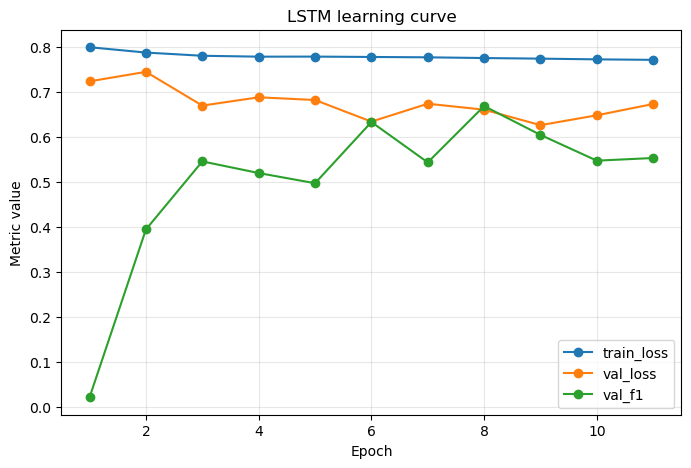

[LSTM] Features shape: (54489, 10), Labels shape: (54489,)
Label distribution:
0    0.939401
1    0.060599
Name: proportion, dtype: float64


predict:   0%|          | 0/426 [00:00<?, ?it/s]

predict:   0%|          | 0/426 [00:00<?, ?it/s]

[LSTM] Features shape: (55653, 10), Labels shape: (55653,)
Label distribution:
0    0.888344
1    0.111656
Name: proportion, dtype: float64


predict:   0%|          | 0/435 [00:00<?, ?it/s]

...

predict:   0%|          | 0/55 [00:00<?, ?it/s]

{'epoch': 3, 'train_loss': 0.7882486262613129, 'val_loss': 0.6923270987609265, 'val_f1': 0.602512523224203}


epoch 4 train:   0%|          | 0/334 [00:00<?, ?it/s]

predict:   0%|          | 0/55 [00:00<?, ?it/s]

{'epoch': 4, 'train_loss': 0.7860491489498874, 'val_loss': 0.6797325300265993, 'val_f1': 0.6233639010852234}
Early stopping at epoch 4


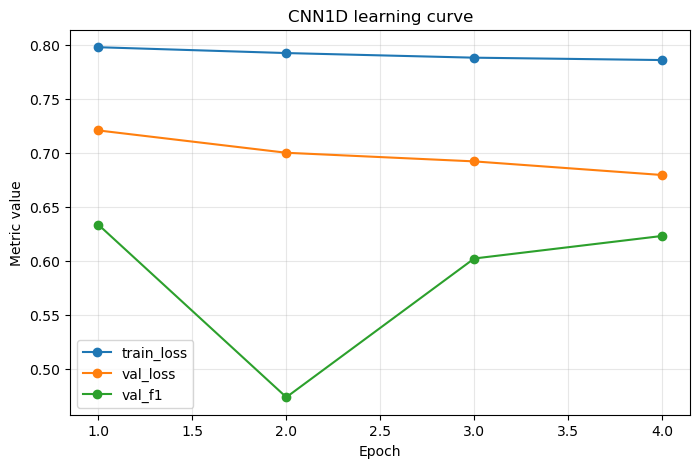

[CNN1D] Features shape: (54489, 10), Labels shape: (54489,)
Label distribution:
0    0.939401
1    0.060599
Name: proportion, dtype: float64


predict:   0%|          | 0/426 [00:00<?, ?it/s]

predict:   0%|          | 0/426 [00:00<?, ?it/s]

[CNN1D] Features shape: (55653, 10), Labels shape: (55653,)
Label distribution:
0    0.888344
1    0.111656
Name: proportion, dtype: float64


predict:   0%|          | 0/435 [00:00<?, ?it/s]

...

[CNN1D] Features shape: (341700, 10), Labels shape: (341700,)
Label distribution:
0    0.576699
1    0.423301
Name: proportion, dtype: float64


predict:   0%|          | 0/2670 [00:00<?, ?it/s]

predict:   0%|          | 0/2670 [00:00<?, ?it/s]

ConvNet              | val_f1=0.6337 | test_f1=0.6688 | seizure_recall=0.6442


,accuracy,precision,recall,f1,precision_seizure,recall_seizure,f1_seizure,roc_auc,val_accuracy,val_precision,...,val_f1_seizure,val_roc_auc,train_accuracy,train_precision,train_recall,train_f1,train_precision_seizure,train_recall_seizure,train_f1_seizure,train_roc_auc
RecurrentNet,0.632586,0.915865,0.632586,0.727857,0.105708,0.678680,0.182924,0.726738,0.593715,0.814112,...,0.202293,0.578213,0.565631,0.574220,0.565631,0.568053,0.488497,0.555178,0.519707,0.601526
ConvNet,0.558994,0.907152,0.558994,0.668769,0.085141,0.644155,0.150403,0.637289,0.551668,0.819281,...,0.212480,0.571336,0.546377,0.566779,0.546377,0.548007,0.472327,0.611323,0.532911,0.570725


In [18]:
class_weights = compute_class_weights(split_frames["train"]["is_seizure"])
scale_pos_weight = compute_scale_pos_weight(split_frames["train"]["is_seizure"])

models = {
    "RecurrentNet": RecurrentNetModel(
    device="cuda",
    hidden_size=64,
    num_layers=4,
    dense_units=(256, 128, 64),
    sequence_length=2,
    dropout=0.2,),
    "ConvNet": ConvNetModel(
        device="cuda",
        num_filters=32,
        kernel_sizes=[3, 5, 7, 9],
        dense_units=(128, 64, 32),
        max_pool_kernel_size=2,)
}

results = {}
trained_models = {}
for name, model in models.items():
    fit_and_score(name, model, results, trained_models)

results_df = pd.DataFrame(results).T.sort_values("val_f1", ascending=False)
results_df

## 6. Results

,accuracy,precision,recall,f1,precision_seizure,recall_seizure,f1_seizure,roc_auc,val_accuracy,val_precision,...,val_f1_seizure,val_roc_auc,train_accuracy,train_precision,train_recall,train_f1,train_precision_seizure,train_recall_seizure,train_f1_seizure,train_roc_auc
RecurrentNet,0.632586,0.915865,0.632586,0.727857,0.105708,0.678680,0.182924,0.726738,0.593715,0.814112,...,0.202293,0.578213,0.565631,0.574220,0.565631,0.568053,0.488497,0.555178,0.519707,0.601526
ConvNet,0.558994,0.907152,0.558994,0.668769,0.085141,0.644155,0.150403,0.637289,0.551668,0.819281,...,0.212480,0.571336,0.546377,0.566779,0.546377,0.548007,0.472327,0.611323,0.532911,0.570725


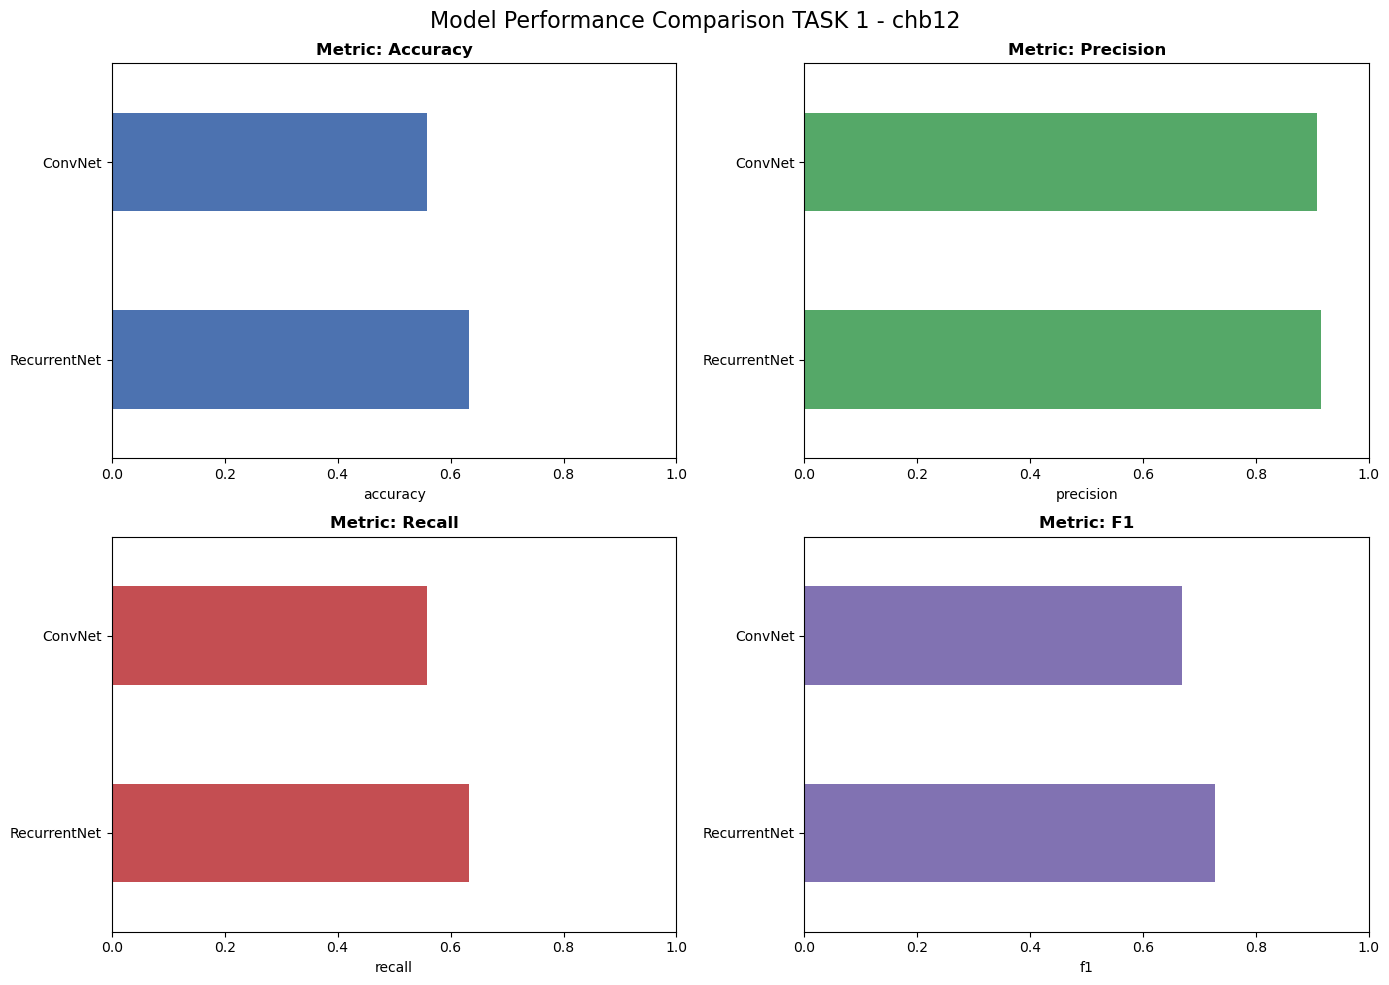

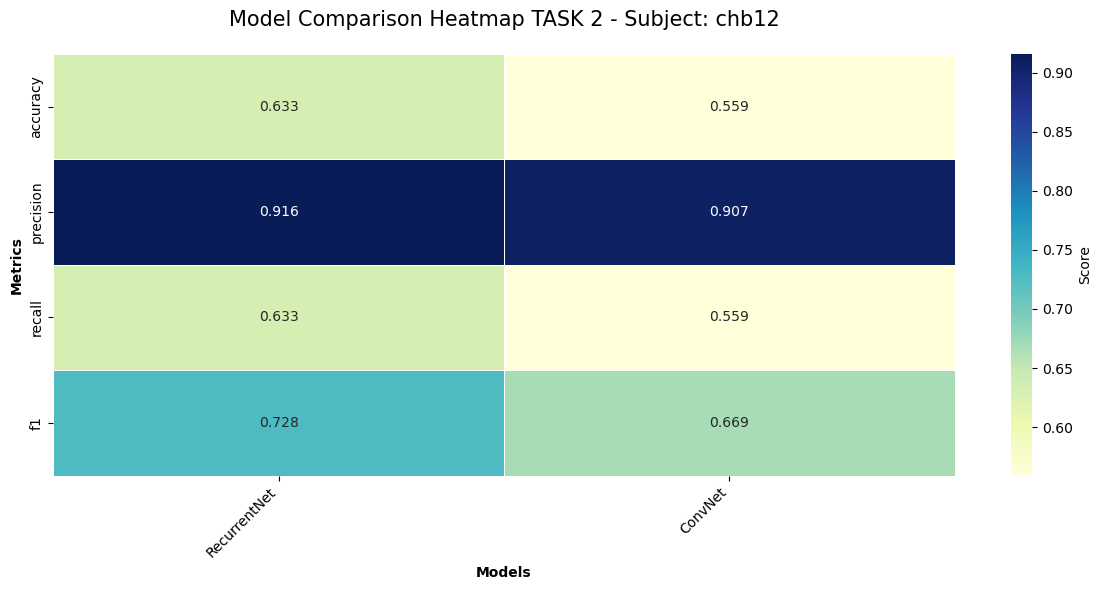

Best model by validation F1: RecurrentNet
accuracy                   0.632586
precision                  0.915865
recall                     0.632586
f1                         0.727857
precision_seizure          0.105708
recall_seizure             0.678680
f1_seizure                 0.182924
roc_auc                    0.726738
val_accuracy               0.593715
val_precision              0.814112
val_recall                 0.593715
val_f1                     0.668813
val_precision_seizure      0.129547
val_recall_seizure         0.461378
val_f1_seizure             0.202293
val_roc_auc                0.578213
train_accuracy             0.565631
train_precision            0.574220
train_recall               0.565631
train_f1                   0.568053
train_precision_seizure    0.488497
train_recall_seizure       0.555178
train_f1_seizure           0.519707
train_roc_auc              0.601526
Name: RecurrentNet, dtype: float64


In [19]:
display(results_df)

metrics = ["accuracy", "precision", "recall", "f1"]
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

# bar chart
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Model Performance Comparison TASK 1 - {SELECTED_SUBJ}", fontsize=16)
for metric, color, ax in zip(metrics, colors, axes.flatten()):
    # sorted_series = results_df[metric].astype(float).sort_values()
    results_df[metric].astype(float).plot(kind="barh", ax=ax, color=color)
    ax.set_title(f"Metric: {metric.capitalize()}", fontweight='bold')
    ax.set_xlabel(metric)
    ax.set_xlim([0, 1])
plt.tight_layout()
plt.show()

if SAVE:
    SAVE_PLOT_PATH.mkdir(parents=True, exist_ok=True)
    plot_file = SAVE_PLOT_PATH / f"task2_barchart_metrics_comparison_{SELECTED_SUBJ}.png"
    fig.savefig(plot_file, dpi=300, bbox_inches='tight')

# heatmap
heatmap_data = results_df[metrics].astype(float).T

fig = plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data, annot=True, fmt=".3f", cmap="YlGnBu", linewidths=.5,cbar_kws={'label': 'Score'}
)

plt.title(f"Model Comparison Heatmap TASK 2 - Subject: {SELECTED_SUBJ}", fontsize=15, pad=20)
plt.xlabel("Models", fontweight='bold')
plt.ylabel("Metrics", fontweight='bold')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

if SAVE:
    SAVE_PLOT_PATH.mkdir(parents=True, exist_ok=True)
    plot_file = SAVE_PLOT_PATH / f"task2_heatmap_metrics_comparison_{SELECTED_SUBJ}.png"
    fig.savefig(plot_file, dpi=300, bbox_inches='tight')

best_model_name = results_df["val_f1"].idxmax()
print(f"Best model by validation F1: {best_model_name}")
print(results_df.loc[best_model_name])


## Prediction on Test split of the best model

predict:   0%|          | 0/426 [00:00<?, ?it/s]

predict:   0%|          | 0/426 [00:00<?, ?it/s]

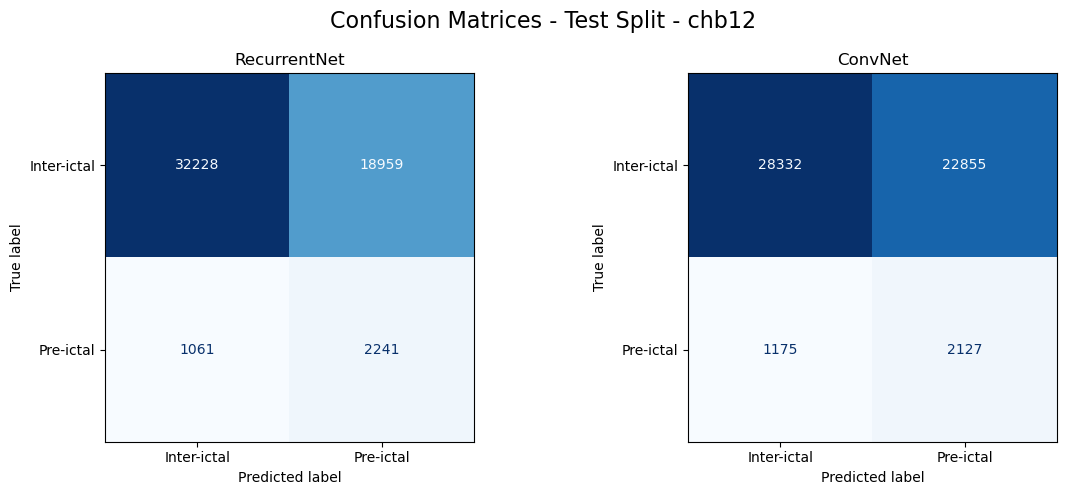

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = ["Inter-ictal", "Pre-ictal"]

n_models = len(trained_models)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5), squeeze=False)
fig.suptitle(f"Confusion Matrices - Test Split - {SELECTED_SUBJ}", fontsize=16)

for ax, (name, model) in zip(axes.flatten(), trained_models.items()):
    X_test, y_test = model.preprocess(split_frames["test"], is_training=False, verbose=False)
    X_test = np.asarray(X_test).astype(np.float32)
    y_test = np.asarray(y_test).astype(int)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(name)

plt.tight_layout()
plt.show()

if SAVE:
    SAVE_PLOT_PATH.mkdir(parents=True, exist_ok=True)
    plot_file = SAVE_PLOT_PATH / f"task2_confusion_matrices_{SELECTED_SUBJ}.png"
    fig.savefig(plot_file, dpi=300, bbox_inches="tight")

## Save Best Trained Model

In [21]:
best_model_name = results_df["val_f1"].idxmax()
best_model = trained_models[best_model_name]

saved_model_path = save_model(
    best_model,
    filename=f"{SELECTED_SUBJ}_{best_model_name}_best_model",
    models_dir=proj_dir / "saved_models" / "task_2",
)
print(f"Saved best model ({best_model_name}) to: {saved_model_path}")


Saved best model (RecurrentNet) to: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/ML_and_DL_for_Healthcare/EEG-epileptic-seizures-detection/saved_models/task_2/chb12_RecurrentNet_best_model.joblib
